# 🎯 MeetPulse — Sentiment Analysis of Meeting Transcripts
**Student:** ADITYA SINGH | Roll No: 23052212 | KIIT University  
**Dataset:** Twitter Entity Sentiment Analysis (Kaggle)  
**Models:** Linear Regression, MLR, Logistic Regression, Decision Tree, SVM, Naive Bayes, K-Means, Hierarchical, DBSCAN, PCA, SVD, SLP, MLP, CNN (+ EarlyStopping), RNN (+ EarlyStopping)  
**Metric:** Accuracy, Precision, Recall, F1  
**GPU:** NVIDIA Tesla P100 (mixed precision, dynamic epoch tuning)

## 📦 1. Imports, GPU Setup & Config

In [1]:
import os, re, glob, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path

warnings.filterwarnings('ignore')

# ── sklearn ────────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_squared_error, r2_score, silhouette_score
)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neural_network import MLPClassifier
from scipy.cluster.hierarchy import dendrogram, linkage

# ── NLTK ───────────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

# ── TensorFlow / Keras ─────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, Embedding, Conv1D,
    GlobalMaxPooling1D, SimpleRNN, BatchNormalization
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.mixed_precision import set_global_policy

np.random.seed(42)
tf.random.set_seed(42)
print('All imports successful')
print('TensorFlow:', tf.__version__)


2026-03-25 07:59:39.904619: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774425580.094014      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774425580.153187      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774425580.622364      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774425580.622410      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774425580.622413      24 computation_placer.cc:177] computation placer alr

All imports successful
TensorFlow: 2.19.0


In [2]:
# ── GPU Detection & Mixed Precision ───────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU detected: {gpus}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    set_global_policy('mixed_float16')   # P100 mixed precision
    print('✅ Mixed precision policy: mixed_float16')
else:
    print('⚠️  No GPU found — falling back to CPU')

print('Devices available:', tf.config.list_logical_devices())


✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Mixed precision policy: mixed_float16
Devices available: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]


I0000 00:00:1774425604.579327      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [3]:
# ── Global Config ─────────────────────────────────────────────────────────
CFG = {
    # Data
    'INPUT_DIR'   : '/kaggle/input',
    'OUTPUT_DIR'  : '/kaggle/working',

    # TF-IDF
    'TFIDF_FEATS' : 5000,
    'NGRAM'       : (1, 2),

    # Sequence (CNN / RNN)
    'MAX_WORDS'   : 10000,
    'MAX_LEN'     : 50,
    'EMBED_DIM'   : 64,
    'BATCH_SIZE'  : 128,      # P100 optimised

    # Dynamic epoch tuning
    'MAX_EPOCHS'  : 25,
    'MIN_EPOCHS'  : 5,
    'PATIENCE'    : 5,        # adaptive per dataset size

    # Classes
    'CLASSES'     : ['Negative', 'Neutral', 'Positive'],
    'NUM_CLASSES' : 3,

    'RANDOM_STATE': 42,
}

Path(CFG['OUTPUT_DIR']).mkdir(parents=True, exist_ok=True)
print('Config loaded:', CFG)


Config loaded: {'INPUT_DIR': '/kaggle/input', 'OUTPUT_DIR': '/kaggle/working', 'TFIDF_FEATS': 5000, 'NGRAM': (1, 2), 'MAX_WORDS': 10000, 'MAX_LEN': 50, 'EMBED_DIM': 64, 'BATCH_SIZE': 128, 'MAX_EPOCHS': 25, 'MIN_EPOCHS': 5, 'PATIENCE': 5, 'CLASSES': ['Negative', 'Neutral', 'Positive'], 'NUM_CLASSES': 3, 'RANDOM_STATE': 42}


## 📊 2. Dataset Loading & Preprocessing

In [4]:
# ── 2.1 Discover files ────────────────────────────────────────────────────
print('Files in /kaggle/input:')
for root, dirs, files in os.walk(CFG['INPUT_DIR']):
    for f in files:
        print(os.path.join(root, f))


Files in /kaggle/input:
/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv
/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv


In [5]:
# ── 2.2 Auto-load all CSVs ────────────────────────────────────────────────
def load_sentiment_csv(path):
    df = pd.read_csv(path, header=None)
    if df.shape[1] == 4:
        df.columns = ['id', 'entity', 'sentiment', 'text']
    elif df.shape[1] == 3:
        df.columns = ['id', 'sentiment', 'text']
    elif df.shape[1] == 2:
        df.columns = ['text', 'sentiment']
    else:
        df = pd.read_csv(path)
    return df

all_csvs = glob.glob(f'{CFG["INPUT_DIR"]}/**/*.csv', recursive=True)
print('Found CSVs:', all_csvs)

dfs = []
for f in all_csvs:
    try:
        dfs.append(load_sentiment_csv(f))
        print('Loaded:', f)
    except Exception as e:
        print('Skipped', f, '->', e)

df_raw = pd.concat(dfs, ignore_index=True)
print('\nRaw shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head()


Found CSVs: ['/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv', '/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv']
Loaded: /kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv
Loaded: /kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv

Raw shape: (75682, 4)
Columns: ['id', 'entity', 'sentiment', 'text']


,id,entity,sentiment,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [6]:
# ── 2.3 Auto-detect columns & clean ──────────────────────────────────────
sentiment_col = None
for col in df_raw.columns:
    vals = df_raw[col].dropna().astype(str).str.strip().unique()
    if any(v in ['Positive','Negative','Neutral','Irrelevant',
                 'positive','negative','neutral'] for v in vals):
        sentiment_col = col
        break

str_cols = df_raw.select_dtypes(include='object').columns.tolist()
text_col  = max(str_cols, key=lambda c: df_raw[c].dropna().astype(str).str.len().mean())

print('Sentiment column:', sentiment_col)
print('Text column     :', text_col)
print('Unique sentiments:', df_raw[sentiment_col].unique())

df = df_raw[[text_col, sentiment_col]].copy()
df.columns = ['text', 'label']
df['label'] = df['label'].astype(str).str.strip().str.capitalize()
df = df[df['label'].isin(['Positive', 'Negative', 'Neutral'])].copy()
df.dropna(subset=['text', 'label'], inplace=True)
df = df[df['text'].astype(str).str.strip() != '']
df.reset_index(drop=True, inplace=True)

# Balance classes
min_count = df['label'].value_counts().min()
df = (df.groupby('label')
        .apply(lambda x: x.sample(min_count, random_state=CFG['RANDOM_STATE']))
        .reset_index(drop=True)
        .sample(frac=1, random_state=CFG['RANDOM_STATE'])
        .reset_index(drop=True))

print('\nBalanced shape:', df.shape)
print(df['label'].value_counts())

# Adaptive patience based on dataset size
if len(df) < 5000:
    CFG['PATIENCE'] = 3
    print('\nSmall dataset → patience set to 3')
elif len(df) > 20000:
    CFG['PATIENCE'] = 7
    print('\nLarge dataset → patience set to 7')
else:
    print(f'\nMedium dataset → patience = {CFG["PATIENCE"]}')


Sentiment column: sentiment
Text column     : text
Unique sentiments: ['Irrelevant' 'Neutral' 'Negative' 'Positive']

Balanced shape: (55008, 2)
label
Negative    18336
Positive    18336
Neutral     18336
Name: count, dtype: int64

Large dataset → patience set to 7


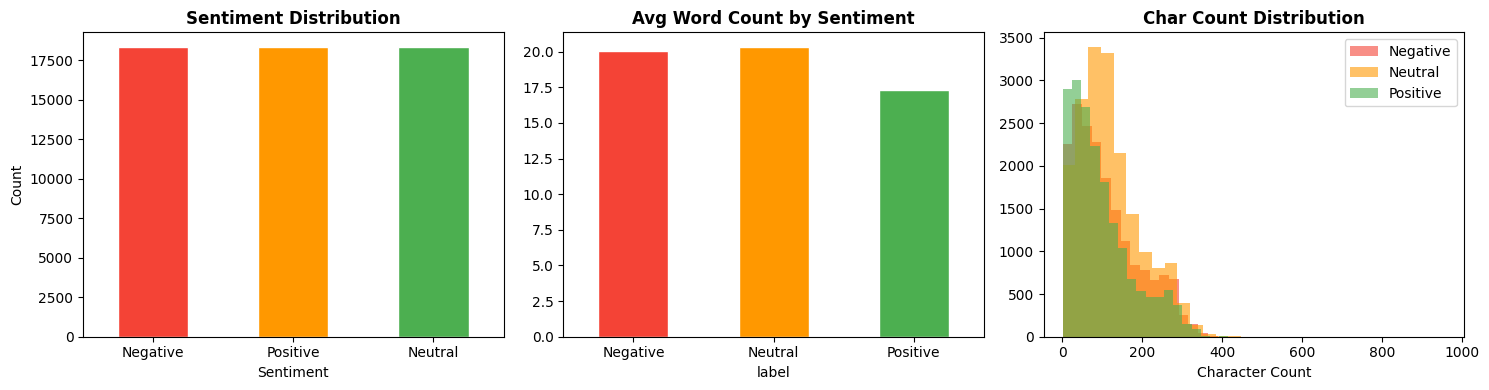

EDA saved.


In [7]:
# ── 2.4 EDA ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label distribution
df['label'].value_counts().plot.bar(ax=axes[0], color=['#F44336','#FF9800','#4CAF50'], edgecolor='white')
axes[0].set_title('Sentiment Distribution', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Word count distribution
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df.groupby('label')['word_count'].mean().plot.bar(ax=axes[1],
    color=['#F44336','#FF9800','#4CAF50'], edgecolor='white')
axes[1].set_title('Avg Word Count by Sentiment', fontweight='bold')
axes[1].tick_params(rotation=0)

# Text length distribution
df['char_count'] = df['text'].apply(len)
for lbl, col in zip(['Negative','Neutral','Positive'], ['#F44336','#FF9800','#4CAF50']):
    subset = df[df['label'] == lbl]['char_count']
    axes[2].hist(subset, bins=30, alpha=0.6, label=lbl, color=col)
axes[2].set_title('Char Count Distribution', fontweight='bold')
axes[2].set_xlabel('Character Count')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{CFG["OUTPUT_DIR"]}/eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA saved.')


In [8]:
# ── 2.5 Text Preprocessing + TF-IDF ──────────────────────────────────────
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

# Label encoding
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])   # Negative=0, Neutral=1, Positive=2

# TF-IDF
tfidf = TfidfVectorizer(max_features=CFG['TFIDF_FEATS'], ngram_range=CFG['NGRAM'])
X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['label_enc'].values

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=CFG['RANDOM_STATE'], stratify=y
)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Classes:', le.classes_)

# Extra features for MLR
df['avg_word_len'] = df['clean_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)


Train: (44006, 5000) | Test: (11002, 5000)
Classes: ['Negative' 'Neutral' 'Positive']


## 📈 3. Regression Models

In [9]:
# ── 3.1 Linear Regression ─────────────────────────────────────────────────
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
lr_pred = lr_reg.predict(X_test)
lr_pred_class = np.clip(np.round(lr_pred), 0, 2).astype(int)
lr_acc = accuracy_score(y_test, lr_pred_class)

print('=== Linear Regression ===')
print('MSE:', round(mean_squared_error(y_test, lr_pred), 4))
print('R2 :', round(r2_score(y_test, lr_pred), 4))
print('Acc:', round(lr_acc, 4))


=== Linear Regression ===
MSE: 0.3543
R2 : 0.4686
Acc: 0.6277


In [10]:
# ── 3.2 Multiple Linear Regression ───────────────────────────────────────
extra = df[['word_count', 'char_count', 'avg_word_len']].values
scaler = MinMaxScaler()
extra_scaled = scaler.fit_transform(extra)
X_multi = sp.hstack([X_tfidf, sp.csr_matrix(extra_scaled)])

Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    X_multi, y, test_size=0.2, random_state=CFG['RANDOM_STATE'], stratify=y
)
mlr = LinearRegression()
mlr.fit(Xm_tr, ym_tr)
mlr_pred = mlr.predict(Xm_te)
mlr_pred_class = np.clip(np.round(mlr_pred), 0, 2).astype(int)

print('=== Multiple Linear Regression ===')
print('MSE:', round(mean_squared_error(ym_te, mlr_pred), 4))
print('R2 :', round(r2_score(ym_te, mlr_pred), 4))
print('Acc:', round(accuracy_score(ym_te, mlr_pred_class), 4))


=== Multiple Linear Regression ===
MSE: 0.3542
R2 : 0.4687
Acc: 0.6282


## 🔍 4. Classification Models

In [11]:
results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te, dense=False):
    if dense:
        X_tr = X_tr.toarray() if hasattr(X_tr, 'toarray') else X_tr
        X_te = X_te.toarray() if hasattr(X_te, 'toarray') else X_te
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc  = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average='macro', zero_division=0)
    rec  = recall_score(y_te, preds, average='macro', zero_division=0)
    f1   = f1_score(y_te, preds, average='macro', zero_division=0)
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f'\n=== {name} ===')
    print('Acc:', round(acc,4), '| Prec:', round(prec,4),
          '| Rec:', round(rec,4), '| F1:', round(f1,4))
    print(classification_report(y_te, preds, target_names=le.classes_, zero_division=0))
    return model, preds

# 4.1 Logistic Regression
log_model, log_preds = evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, C=1.0, random_state=CFG['RANDOM_STATE']),
    X_train, X_test, y_train, y_test
)

# 4.2 Decision Tree
dt_model, dt_preds = evaluate(
    'Decision Tree',
    DecisionTreeClassifier(max_depth=20, min_samples_split=5, random_state=CFG['RANDOM_STATE']),
    X_train, X_test, y_train, y_test
)

# 4.3 SVM (best sklearn model for deployment)
svm_model, svm_preds = evaluate(
    'SVM (Linear)',
    SVC(kernel='linear', probability=True, C=1.0, random_state=CFG['RANDOM_STATE']),
    X_train, X_test, y_train, y_test
)

# 4.4 Naive Bayes
nb_model, nb_preds = evaluate(
    'Naive Bayes',
    MultinomialNB(alpha=0.1),
    X_train, X_test, y_train, y_test
)

print('\n✅ All classifiers done.')



=== Logistic Regression ===
Acc: 0.7463 | Prec: 0.7467 | Rec: 0.7463 | F1: 0.7465
              precision    recall  f1-score   support

    Negative       0.77      0.76      0.76      3667
     Neutral       0.71      0.72      0.72      3667
    Positive       0.76      0.76      0.76      3668

    accuracy                           0.75     11002
   macro avg       0.75      0.75      0.75     11002
weighted avg       0.75      0.75      0.75     11002


=== Decision Tree ===
Acc: 0.5105 | Prec: 0.6172 | Rec: 0.5105 | F1: 0.4917
              precision    recall  f1-score   support

    Negative       0.69      0.29      0.41      3667
     Neutral       0.41      0.86      0.56      3667
    Positive       0.75      0.38      0.51      3668

    accuracy                           0.51     11002
   macro avg       0.62      0.51      0.49     11002
weighted avg       0.62      0.51      0.49     11002


=== SVM (Linear) ===
Acc: 0.7594 | Prec: 0.7598 | Rec: 0.7594 | F1: 0.7596
  

## 🧠 5. Neural Networks

In [12]:
# ── 5.1 Single Layer Perceptron ──────────────────────────────────────────
slp_model, slp_preds = evaluate(
    'Single Layer Perceptron',
    MLPClassifier(hidden_layer_sizes=(), max_iter=300, random_state=CFG['RANDOM_STATE']),
    X_train, X_test, y_train, y_test
)

# ── 5.2 Multi Layer Perceptron ───────────────────────────────────────────
mlp_model, mlp_preds = evaluate(
    'Multi Layer Perceptron',
    MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                  random_state=CFG['RANDOM_STATE'], early_stopping=True, validation_fraction=0.1),
    X_train, X_test, y_train, y_test
)



=== Single Layer Perceptron ===
Acc: 0.7714 | Prec: 0.7721 | Rec: 0.7714 | F1: 0.7716
              precision    recall  f1-score   support

    Negative       0.80      0.77      0.79      3667
     Neutral       0.74      0.76      0.75      3667
    Positive       0.78      0.78      0.78      3668

    accuracy                           0.77     11002
   macro avg       0.77      0.77      0.77     11002
weighted avg       0.77      0.77      0.77     11002


=== Multi Layer Perceptron ===
Acc: 0.8804 | Prec: 0.8826 | Rec: 0.8804 | F1: 0.8805
              precision    recall  f1-score   support

    Negative       0.92      0.86      0.88      3667
     Neutral       0.89      0.87      0.88      3667
    Positive       0.84      0.92      0.88      3668

    accuracy                           0.88     11002
   macro avg       0.88      0.88      0.88     11002
weighted avg       0.88      0.88      0.88     11002



In [13]:
# ── 5.3 Sequence preparation (CNN + RNN) ─────────────────────────────────
MAX_WORDS = CFG['MAX_WORDS']
MAX_LEN   = CFG['MAX_LEN']
EMBED_DIM = CFG['EMBED_DIM']
BATCH     = CFG['BATCH_SIZE']

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])
texts_seq = tokenizer.texts_to_sequences(df['clean_text'])
texts_pad = pad_sequences(texts_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_cat = to_categorical(y, num_classes=CFG['NUM_CLASSES'])

Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    texts_pad, y_cat, test_size=0.2,
    random_state=CFG['RANDOM_STATE'], stratify=y
)
yd_tr_int = np.argmax(yd_tr, axis=1)
yd_te_int = np.argmax(yd_te, axis=1)
print('Seq shapes — Train:', Xd_tr.shape, '| Test:', Xd_te.shape)


Seq shapes — Train: (44006, 50) | Test: (11002, 50)


In [14]:
# ── 5.4 Shared Keras Callbacks (Dynamic Epoch Tuning) ────────────────────
def get_callbacks(model_name, monitor='val_accuracy', mode='max'):
    """
    Returns EarlyStopping + ReduceLROnPlateau + ModelCheckpoint.
    Early stopping uses adaptive patience from CFG.
    Minimum epochs enforced via min_delta threshold.
    """
    ckpt_path = f'{CFG["OUTPUT_DIR"]}/{model_name}_best.keras'
    callbacks = [
        EarlyStopping(
            monitor=monitor,
            mode=mode,
            patience=CFG['PATIENCE'],
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            mode=mode,
            factor=0.5,
            patience=max(2, CFG['PATIENCE'] // 2),
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor=monitor,
            mode=mode,
            save_best_only=True,
            verbose=0
        ),
    ]
    return callbacks, ckpt_path

print(f'Dynamic epoch config — max: {CFG["MAX_EPOCHS"]} | min: {CFG["MIN_EPOCHS"]} | patience: {CFG["PATIENCE"]}')


Dynamic epoch config — max: 25 | min: 5 | patience: 7


In [15]:
# ── 5.5 CNN (GPU, mixed precision, dynamic epochs) ───────────────────────
cnn = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    BatchNormalization(),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(CFG['NUM_CLASSES'], activation='softmax', dtype='float32')  # fp32 output
], name='CNN')

cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn.summary()

cnn_callbacks, cnn_ckpt = get_callbacks('cnn')

print('\n🚀 Training CNN with dynamic epoch tuning (min=5, max=25, patience=', CFG['PATIENCE'], ')')
cnn_history = cnn.fit(
    Xd_tr, yd_tr,
    epochs=CFG['MAX_EPOCHS'],
    batch_size=BATCH,
    validation_split=0.1,
    callbacks=cnn_callbacks,
    verbose=1
)

# Enforce minimum epochs — if stopped early < MIN_EPOCHS, re-run without early stopping
actual_cnn_epochs = len(cnn_history.history['loss'])
if actual_cnn_epochs < CFG['MIN_EPOCHS']:
    print(f'\n⚠️  Stopped at {actual_cnn_epochs} epochs < min {CFG["MIN_EPOCHS"]}. Resuming...')
    cnn.fit(Xd_tr, yd_tr, epochs=CFG['MIN_EPOCHS'] - actual_cnn_epochs,
            batch_size=BATCH, validation_split=0.1, verbose=1)

_, cnn_acc = cnn.evaluate(Xd_te, yd_te, verbose=0)
cnn_preds  = np.argmax(cnn.predict(Xd_te), axis=1)
results['CNN'] = {
    'Accuracy':  cnn_acc,
    'Precision': precision_score(yd_te_int, cnn_preds, average='macro', zero_division=0),
    'Recall':    recall_score(yd_te_int, cnn_preds, average='macro', zero_division=0),
    'F1':        f1_score(yd_te_int, cnn_preds, average='macro', zero_division=0)
}
print(f'\n✅ CNN — Acc: {cnn_acc:.4f} | F1: {results["CNN"]["F1"]:.4f} | Epochs run: {actual_cnn_epochs}')
print('Best checkpoint saved to:', cnn_ckpt)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Training CNN with dynamic epoch tuning (min=5, max=25, patience= 7 )
Epoch 1/25


I0000 00:00:1774426903.114473      67 service.cc:152] XLA service 0x7cb2b000c8f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774426903.114525      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774426903.694358      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


 42/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4005 - loss: 1.1703

I0000 00:00:1774426906.640932      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


310/310 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5412 - loss: 0.9478 - val_accuracy: 0.7839 - val_loss: 0.9057 - learning_rate: 0.0010
Epoch 2/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8350 - loss: 0.4252 - val_accuracy: 0.8380 - val_loss: 0.4362 - learning_rate: 0.0010
Epoch 3/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9168 - loss: 0.2168 - val_accuracy: 0.8534 - val_loss: 0.4253 - learning_rate: 0.0010
Epoch 4/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9352 - loss: 0.1633 - val_accuracy: 0.8541 - val_loss: 0.4658 - learning_rate: 0.0010
Epoch 5/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9480 - loss: 0.1257 - val_accuracy: 0.8559 - val_loss: 0.4965 - learning_rate: 0.0010
Epoch 6/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9546 - loss: 0.1084 - val_accuracy: 0.8525 - val_loss: 0.5761 - learning_rate: 0.0010
Epoch 7/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9573 - loss: 0.0981 - val_accur

In [16]:
# ── 5.6 RNN (SimpleRNN, dynamic epochs) ──────────────────────────────────
rnn = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(CFG['NUM_CLASSES'], activation='softmax', dtype='float32')
], name='RNN')

rnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_callbacks, rnn_ckpt = get_callbacks('rnn')

print('\n🚀 Training RNN with dynamic epoch tuning...')
rnn_history = rnn.fit(
    Xd_tr, yd_tr,
    epochs=CFG['MAX_EPOCHS'],
    batch_size=BATCH,
    validation_split=0.1,
    callbacks=rnn_callbacks,
    verbose=1
)

actual_rnn_epochs = len(rnn_history.history['loss'])
if actual_rnn_epochs < CFG['MIN_EPOCHS']:
    rnn.fit(Xd_tr, yd_tr, epochs=CFG['MIN_EPOCHS'] - actual_rnn_epochs,
            batch_size=BATCH, validation_split=0.1, verbose=1)

_, rnn_acc = rnn.evaluate(Xd_te, yd_te, verbose=0)
rnn_preds  = np.argmax(rnn.predict(Xd_te), axis=1)
results['RNN'] = {
    'Accuracy':  rnn_acc,
    'Precision': precision_score(yd_te_int, rnn_preds, average='macro', zero_division=0),
    'Recall':    recall_score(yd_te_int, rnn_preds, average='macro', zero_division=0),
    'F1':        f1_score(yd_te_int, rnn_preds, average='macro', zero_division=0)
}
print(f'\n✅ RNN — Acc: {rnn_acc:.4f} | F1: {results["RNN"]["F1"]:.4f} | Epochs run: {actual_rnn_epochs}')
print('Best checkpoint saved to:', rnn_ckpt)



🚀 Training RNN with dynamic epoch tuning...
Epoch 1/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.3356 - loss: 1.1392 - val_accuracy: 0.3408 - val_loss: 1.5371 - learning_rate: 0.0010
Epoch 2/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3338 - loss: 1.0988 - val_accuracy: 0.3333 - val_loss: 1.1011 - learning_rate: 0.0010
Epoch 3/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3317 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.1572 - learning_rate: 0.0010
Epoch 4/25
305/310 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3332 - loss: 1.0986
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3332 - loss: 1.0986 - val_accuracy: 0.3258 - val_loss: 1.0997 - learning_rate: 0.0010
Epoch 5/25
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3316 - loss: 1.0986 - val_accuracy: 0.3333 - val_loss: 1.1383 - learning_rate: 5.0000e-04
Epoch 6/25
310/310 ━━━━━━━━━━━━━━━━━━━

## 🔵 6. Clustering

In [17]:
# PCA 2D for clustering vis
pca_2d = PCA(n_components=2)
X_2d   = pca_2d.fit_transform(X_tfidf.toarray()[:2000])
y_sub  = y[:2000]

# 6.1 K-Means
kmeans    = KMeans(n_clusters=3, random_state=CFG['RANDOM_STATE'], n_init=10)
km_labels = kmeans.fit_predict(X_2d)
sil       = silhouette_score(X_2d, km_labels)
print('=== K-Means === Silhouette:', round(sil, 4))

# 6.2 Hierarchical
Z = linkage(X_2d[:200], method='ward')
print('=== Hierarchical Clustering === done')

# 6.3 DBSCAN
dbscan    = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_2d)
n_clust   = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise   = list(db_labels).count(-1)
print('=== DBSCAN === Clusters:', n_clust, '| Noise pts:', n_noise)


=== K-Means === Silhouette: 0.9379
=== Hierarchical Clustering === done
=== DBSCAN === Clusters: 1 | Noise pts: 0


## 🔻 7. Dimensionality Reduction

In [18]:
# 7.1 PCA
pca_full = PCA(n_components=100)
X_pca    = pca_full.fit_transform(X_tfidf.toarray())
expl     = np.cumsum(pca_full.explained_variance_ratio_)
print('PCA 100 components variance:', round(expl[-1]*100, 1), '%')

# 7.2 SVD (LSA)
svd   = TruncatedSVD(n_components=100, random_state=CFG['RANDOM_STATE'])
X_svd = svd.fit_transform(X_tfidf)
print('SVD 100 components variance:', round(np.sum(svd.explained_variance_ratio_)*100, 1), '%')

# 7.3 LR on SVD features
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_svd, y, test_size=0.2, random_state=CFG['RANDOM_STATE'], stratify=y
)
lr_svd = LogisticRegression(max_iter=500, random_state=CFG['RANDOM_STATE'])
lr_svd.fit(Xr_tr, yr_tr)
svd_preds = lr_svd.predict(Xr_te)
svd_acc   = accuracy_score(yr_te, svd_preds)
results['LR + SVD'] = {
    'Accuracy':  svd_acc,
    'Precision': precision_score(yr_te, svd_preds, average='macro', zero_division=0),
    'Recall':    recall_score(yr_te, svd_preds, average='macro', zero_division=0),
    'F1':        f1_score(yr_te, svd_preds, average='macro', zero_division=0)
}
print('LR+SVD Acc:', round(svd_acc, 4))


PCA 100 components variance: 22.6 %
SVD 100 components variance: 22.5 %
LR+SVD Acc: 0.5962


## 📊 8. Visualizations

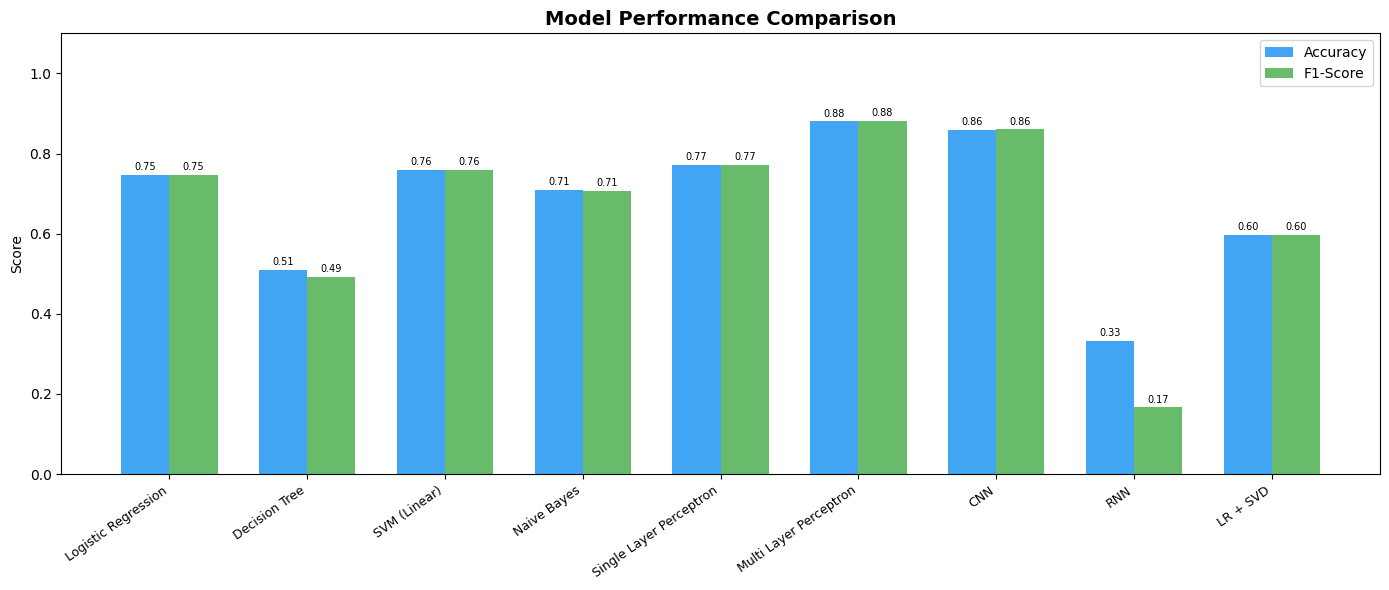

Saved model_comparison.png


In [19]:
# ── 8.1 Model Accuracy vs F1 ─────────────────────────────────────────────
model_names = list(results.keys())
accuracies  = [results[m]['Accuracy'] for m in model_names]
f1_scores   = [results[m]['F1'] for m in model_names]

x     = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#2196F3', alpha=0.85)
b2 = ax.bar(x + width/2, f1_scores,  width, label='F1-Score',  color='#4CAF50', alpha=0.85)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.legend()
ax.bar_label(b1, fmt='%.2f', fontsize=7, padding=2)
ax.bar_label(b2, fmt='%.2f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(f'{CFG["OUTPUT_DIR"]}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved model_comparison.png')


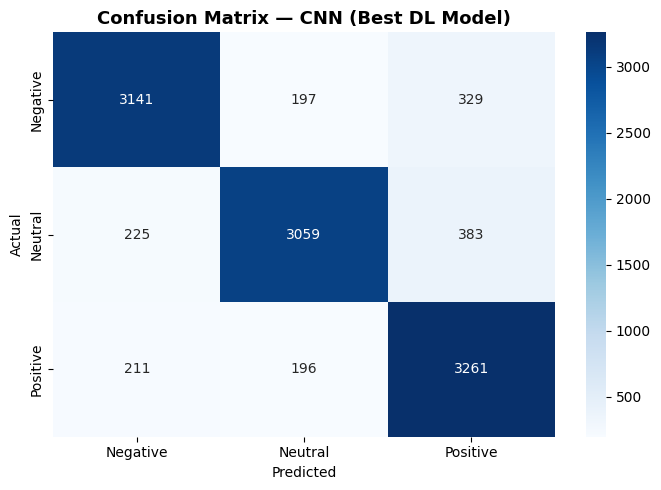

Saved confusion_matrix.png


In [20]:
# ── 8.2 Confusion Matrix — CNN ────────────────────────────────────────────
cm = confusion_matrix(yd_te_int, cnn_preds)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Confusion Matrix — CNN (Best DL Model)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{CFG["OUTPUT_DIR"]}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix.png')


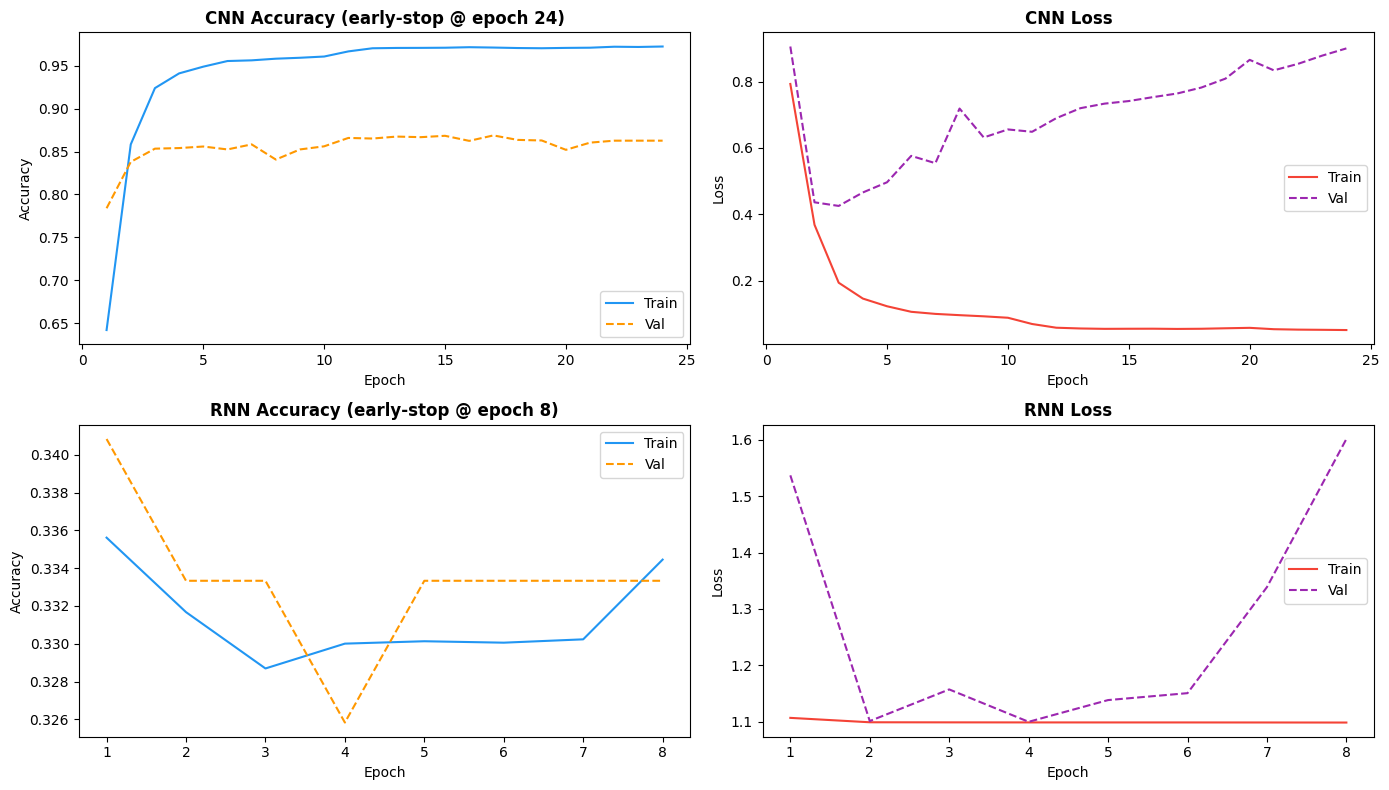

Saved training_curves.png


In [21]:
# ── 8.3 Training Curves — CNN & RNN ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (hist, name) in enumerate([(cnn_history, 'CNN'), (rnn_history, 'RNN')]):
    ax_acc  = axes[row][0]
    ax_loss = axes[row][1]
    epochs_ran = range(1, len(hist.history['accuracy']) + 1)

    ax_acc.plot(epochs_ran, hist.history['accuracy'],     label='Train', color='#2196F3')
    ax_acc.plot(epochs_ran, hist.history['val_accuracy'], label='Val',   color='#FF9800', linestyle='--')
    ax_acc.set_title(f'{name} Accuracy (early-stop @ epoch {len(epochs_ran)})', fontweight='bold')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

    ax_loss.plot(epochs_ran, hist.history['loss'],     label='Train', color='#F44336')
    ax_loss.plot(epochs_ran, hist.history['val_loss'], label='Val',   color='#9C27B0', linestyle='--')
    ax_loss.set_title(f'{name} Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend()

plt.tight_layout()
plt.savefig(f'{CFG["OUTPUT_DIR"]}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')


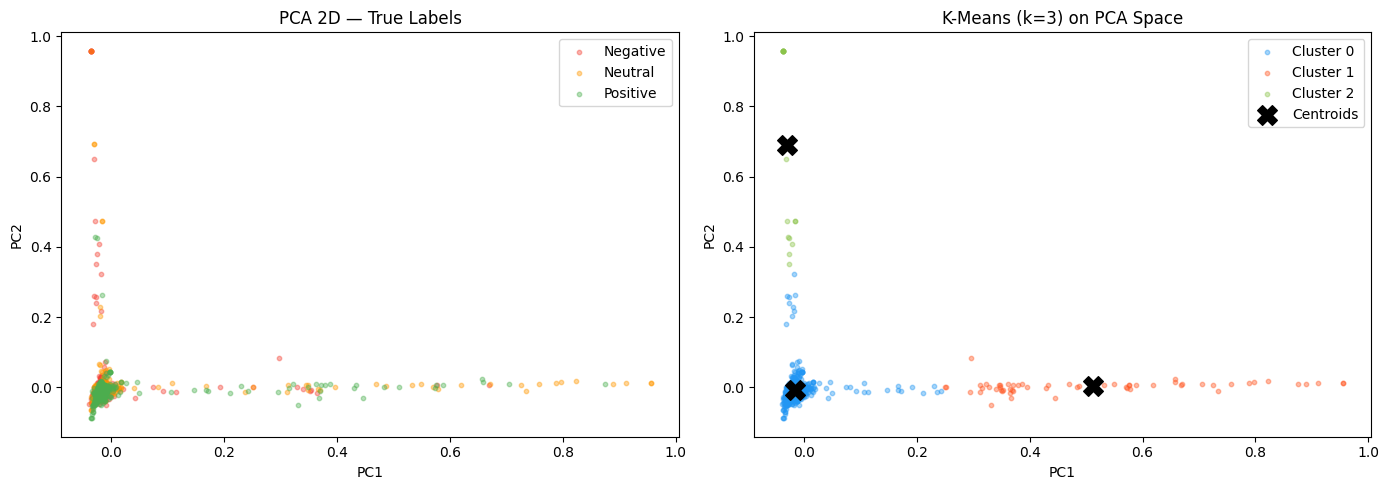

Saved clustering.png


In [22]:
# ── 8.4 PCA + K-Means Scatter ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#F44336', '#FF9800', '#4CAF50']
for i, (cls, col) in enumerate(zip(le.classes_, colors)):
    mask = y_sub == i
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1], c=col, label=cls, alpha=0.4, s=10)
ax1.set_title('PCA 2D — True Labels'); ax1.legend(); ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

for i, col in enumerate(['#2196F3', '#FF5722', '#8BC34A']):
    mask = km_labels == i
    ax2.scatter(X_2d[mask, 0], X_2d[mask, 1], c=col, label='Cluster '+str(i), alpha=0.4, s=10)
ax2.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')
ax2.set_title('K-Means (k=3) on PCA Space'); ax2.legend(); ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
plt.tight_layout()
plt.savefig(f'{CFG["OUTPUT_DIR"]}/clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved clustering.png')


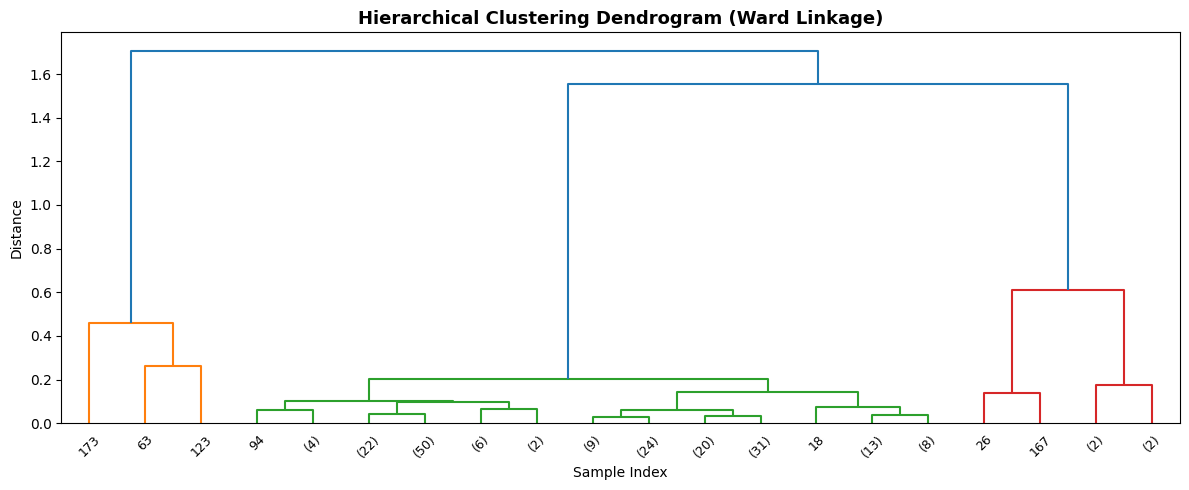

Saved dendrogram.png


In [23]:
# ── 8.5 Hierarchical Dendrogram ──────────────────────────────────────────
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=9)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=13, fontweight='bold')
plt.xlabel('Sample Index'); plt.ylabel('Distance')
plt.tight_layout()
plt.savefig(f'{CFG["OUTPUT_DIR"]}/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved dendrogram.png')


In [24]:
# ── 8.6 Learning Rate Trace (CNN) ────────────────────────────────────────
if 'lr' in cnn_history.history:
    plt.figure(figsize=(8, 3))
    plt.plot(cnn_history.history['lr'], color='#9C27B0', marker='o', markersize=4)
    plt.title('CNN Learning Rate Schedule (ReduceLROnPlateau)', fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('LR')
    plt.yscale('log')
    plt.tight_layout()
    plt.savefig(f'{CFG["OUTPUT_DIR"]}/lr_schedule.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved lr_schedule.png')
else:
    print('LR history not tracked (single LR epoch run).')


LR history not tracked (single LR epoch run).


## 🏆 9. Best Model & Export

In [25]:
# ── Full results table ───────────────────────────────────────────────────
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
print('=== MODEL COMPARISON (sorted by F1) ===')
print(results_df.round(4).to_string())

best_name = results_df.index[0]
print('\n🥇 BEST MODEL:', best_name)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    print(f'  {metric:10s}: {results_df.loc[best_name, metric]:.4f}')


=== MODEL COMPARISON (sorted by F1) ===
                         Accuracy  Precision  Recall      F1
Multi Layer Perceptron     0.8804     0.8826  0.8804  0.8805
CNN                        0.8599     0.8617  0.8599  0.8600
Single Layer Perceptron    0.7714     0.7721  0.7714  0.7716
SVM (Linear)               0.7594     0.7598  0.7594  0.7596
Logistic Regression        0.7463     0.7467  0.7463  0.7465
Naive Bayes                0.7087     0.7108  0.7087  0.7066
LR + SVD                   0.5962     0.6002  0.5962  0.5971
Decision Tree              0.5105     0.6172  0.5105  0.4917
RNN                        0.3333     0.1111  0.3333  0.1667

🥇 BEST MODEL: Multi Layer Perceptron
  Accuracy  : 0.8804
  Precision : 0.8826
  Recall    : 0.8804
  F1        : 0.8805


In [26]:
# ── Export deployment artifacts ──────────────────────────────────────────
OUT = CFG['OUTPUT_DIR']

# SVM chosen for pkl-based FastAPI/Streamlit deploy (no TF dependency)
joblib.dump(svm_model, f'{OUT}/model.pkl')
joblib.dump(tfidf,     f'{OUT}/tfidf.pkl')
joblib.dump(le,        f'{OUT}/label_encoder.pkl')
print('Exported: model.pkl, tfidf.pkl, label_encoder.pkl')

# CNN Keras model
cnn.save(f'{OUT}/cnn_model.keras')
print('Exported: cnn_model.keras')

# Round-trip verification
m2  = joblib.load(f'{OUT}/model.pkl')
t2  = joblib.load(f'{OUT}/tfidf.pkl')
le2 = joblib.load(f'{OUT}/label_encoder.pkl')
test_phrases = [
    'great progress team delivered on time',
    'build is broken pipeline keeps failing',
    'reviewed backlog items and story points'
]
for phrase in test_phrases:
    pred = m2.predict(t2.transform([phrase]))
    print(f'  [{phrase[:45]}] → {le2.inverse_transform(pred)[0]}')

print('\n✅ All output files ready in', OUT)
print('Files:', os.listdir(OUT))


Exported: model.pkl, tfidf.pkl, label_encoder.pkl
Exported: cnn_model.keras
  [great progress team delivered on time] → Positive
  [build is broken pipeline keeps failing] → Negative
  [reviewed backlog items and story points] → Negative

✅ All output files ready in /kaggle/working
Files: ['eda.png', 'tfidf.pkl', 'label_encoder.pkl', 'model_comparison.png', 'dendrogram.png', 'clustering.png', 'confusion_matrix.png', 'rnn_best.keras', 'training_curves.png', 'cnn_best.keras', 'model.pkl', '__notebook__.ipynb', 'cnn_model.keras']
